In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [12]:
df = pd.read_csv("spam.csv", encoding="latin-1")[['v1','v2']]  # keep only needed columns
df.dropna(inplace=True)  # remove any empty rows
df['v2'] = df['v2'].str.lower().str.strip()  # lowercase and remove extra spaces


In [13]:
df["v1"] = df["v1"].map({"ham": 0, "spam": 1})


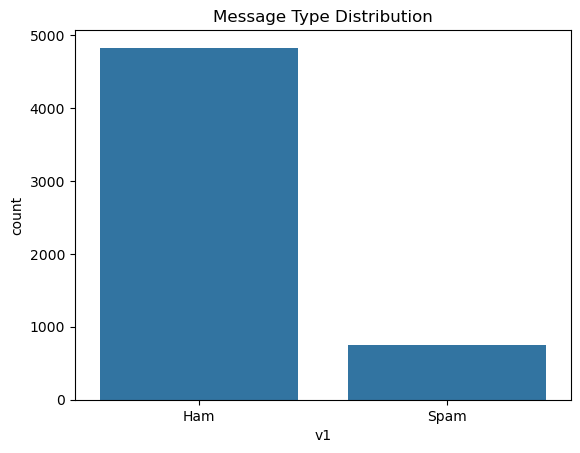

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='v1', data=df)
plt.xticks([0,1], ['Ham','Spam'])
plt.title("Message Type Distribution")
plt.show()


In [15]:
X = df["v2"]
y = df["v1"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)  # include unigrams and bigrams for better accuracy
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [17]:
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_vec, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
y_pred = svm_model.predict(X_test_vec)


Accuracy: 0.9829596412556054

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.89      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



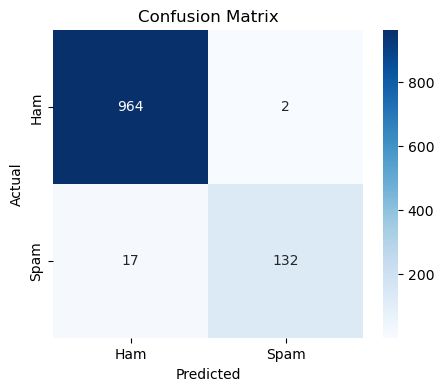

In [19]:


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")
plt.show()


In [20]:
import joblib
joblib.dump(svm_model, 'svm_spam_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')



['tfidf_vectorizer.pkl']